# Fine-Tuning RoBERTa-base for Mental Health Severity Scoring (1–10)

## 1. Install Dependencies

In [1]:
!pip install -q transformers>=4.45.0 datasets scikit-learn>=1.5.0 accelerate openpyxl

## 2. Imports & Reproducibility

In [2]:
import os, gc, math, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    mean_absolute_error, cohen_kappa_score, confusion_matrix,
)
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 3. Load & Clean Data

In [3]:
# ---- Load your labeled CSV/Excel ----
# Expected columns: text, label (0/1 binary), qwen_score (1-10), qwen_rating
df = pd.read_excel('NLP_qwen_labels_output.xlsx')   # <-- adjust path if needed
print(f'Loaded: {len(df)} rows')
print(df.isna().sum())
df.head(3)

Loaded: 27977 rows
text                        2
label                       0
qwen_score                  0
Qwen_Labels                 0
qwen_rating                 0
qwen_reasoning              0
qwen_dominant_signals    1166
dtype: int64


,text,label,qwen_score,Qwen_Labels,qwen_rating,qwen_reasoning,qwen_dominant_signals
0,dear american teens question dutch person hear...,0,1,{'reasoning': 'The text contains no emotional ...,BEST,The text contains no emotional content or dist...,"neutral communication, educational inquiry, no..."
1,nothing look forward lifei dont many reasons k...,1,9,"{'reasoning': ""The text explicitly states suic...",VERY_VERY_BAD,The text explicitly states suicidal ideation (...,"suicidal ideation, hopelessness, no future ori..."
2,music recommendations im looking expand playli...,0,2,{'reasoning': 'The text focuses solely on requ...,VERY_GOOD,The text focuses solely on requesting music re...,"music interest, genre exploration, social enga..."


In [4]:
# ---- Drop nulls in required columns ----
df = df.dropna(subset=['text', 'label', 'qwen_score', 'qwen_rating']).reset_index(drop=True)

# ---- Drop auxiliary columns we won't use ----
drop_cols = [c for c in ['qwen_reasoning', 'qwen_dominant_signals', 'Qwen_Labels'] if c in df.columns]
df = df.drop(columns=drop_cols)

# ---- FIX: Filter incompatible rows ----
# label=1 (mental health issue)   -> qwen_score must be 6..10
# label=0 (no mental health issue) -> qwen_score must be 1..5
# Any row that violates this is contradictory and should be dropped.
contradictory = (
    ((df['label'] == 1) & (df['qwen_score'] <= 5)) |
    ((df['label'] == 0) & (df['qwen_score'] >= 6))
)
print(f'Contradictory rows dropped: {contradictory.sum()}')
df = df[~contradictory].reset_index(drop=True)

# ---- Drop very short / empty texts ----
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'].str.len() >= 3].reset_index(drop=True)

# ---- Convert qwen_score 1..10 -> class index 0..9 ----
df['class_label'] = df['qwen_score'].astype(int) - 1

print(f'\nFinal dataset: {len(df)} rows')
print(df.shape)

Contradictory rows dropped: 2

Final dataset: 27972 rows
(27972, 5)


In [5]:
RATING_NAMES = ['BEST', 'VERY_GOOD', 'GOOD', 'MODERATE_GOOD', 'NEUTRAL',
                'MODERATE_BAD', 'BAD', 'VERY_BAD', 'VERY_VERY_BAD', 'WORST']

dist = df['class_label'].value_counts().sort_index()
print('=== Class distribution ===')
for i, name in enumerate(RATING_NAMES):
    count = dist.get(i, 0)
    pct = 100 * count / len(df)
    bar = '#' * int(pct)
    print(f'{i+1:2d} {name:<14} {count:>5}  ({pct:>5.1f}%) {bar}')

=== Class distribution ===
 1 BEST            6493  ( 23.2%) #######################
 2 VERY_GOOD       2380  (  8.5%) ########
 3 GOOD            1162  (  4.2%) ####
 4 MODERATE_GOOD   3065  ( 11.0%) ##########
 5 NEUTRAL         1037  (  3.7%) ###
 6 MODERATE_BAD    2067  (  7.4%) #######
 7 BAD              880  (  3.1%) ###
 8 VERY_BAD        1008  (  3.6%) ###
 9 VERY_VERY_BAD   8055  ( 28.8%) ############################
10 WORST           1825  (  6.5%) ######


## 4. Configuration

In [6]:
# ===================== MODEL =====================
MODEL_NAME   = 'roberta-base'   # <-- RoBERTa-base (125M params, 12 layers)

# ===================== DATA =====================
NUM_LABELS   = 10
MAX_LENGTH   = 256
STRIDE       = 128              # sliding-window overlap for long texts

# ===================== TRAINING =====================
BATCH_SIZE   = 16               # reduce to 8 + set GRAD_ACCUM=2 if OOM
GRAD_ACCUM   = 1
EPOCHS       = 6                # early stopping will cut short
LR           = 2e-5
WEIGHT_DECAY = 0.05
WARMUP_RATIO = 0.1
LABEL_SMOOTH = 0.1              # smooths noisy LLM labels
LLRD         = 0.9              # layer-wise LR decay factor
PATIENCE     = 2                # early stopping patience (epochs)
DROPOUT      = 0.2              # applied to hidden + attention layers

OUTPUT_DIR   = './roberta_mental_severity'
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 5. Stratified Train / Val / Test Split  (70 / 15 / 15)

In [7]:
train_df, temp_df = train_test_split(
    df, test_size=0.20, random_state=SEED, stratify=df['class_label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['class_label']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
pct_train = 100*len(train_df)/len(df)
pct_val   = 100*len(val_df)/len(df)
pct_test  = 100*len(test_df)/len(df)
print(f'Ratios:  {pct_train:.1f}% / {pct_val:.1f}% / {pct_test:.1f}%')

# ---- Save test split now (used again for prompt engineering comparison) ----
test_df.to_csv(f'{OUTPUT_DIR}/test_split.csv', index=False)
print(f'Test split saved to {OUTPUT_DIR}/test_split.csv')

# ---- Class weights (computed on TRAIN only) to handle imbalance ----
class_weights = compute_class_weight(
    'balanced',
    classes=np.arange(NUM_LABELS),
    y=train_df['class_label'].values,
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print('\nClass weights (balanced):')
for i, (name, w) in enumerate(zip(RATING_NAMES, class_weights.cpu().numpy())):
    print(f'  {i+1:2d} {name:<14} {w:.3f}')

Train: 22377 | Val: 2797 | Test: 2798
Ratios:  80.0% / 10.0% / 10.0%
Test split saved to ./roberta_mental_severity/test_split.csv

Class weights (balanced):
   1 BEST           0.431
   2 VERY_GOOD      1.175
   3 GOOD           2.406
   4 MODERATE_GOOD  0.913
   5 NEUTRAL        2.696
   6 MODERATE_BAD   1.354
   7 BAD            3.179
   8 VERY_BAD       2.776
   9 VERY_VERY_BAD  0.347
  10 WORST          1.533


## 6. Tokenize with Sliding Window (handles long texts)

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess_sliding(texts, labels, name=''):
    """
    Long texts are split into overlapping chunks; each chunk inherits the parent label.
    `sample_ids` maps each chunk back to its parent row for aggregation at inference time.

    NOTE: RoBERTa does NOT use token_type_ids — we intentionally exclude them.
    """
    ids, masks, lbls, sids = [], [], [], []
    long_count = 0
    for idx, (t, y) in enumerate(tqdm(list(zip(texts, labels)), desc=f'Tokenize [{name}]')):
        enc = tokenizer(
            str(t),
            max_length=MAX_LENGTH,
            stride=STRIDE,
            truncation=True,
            padding='max_length',
            return_overflowing_tokens=True,
            return_tensors='pt',
            # token_type_ids are NOT returned for RoBERTa (tokenizer handles this)
        )
        n = enc['input_ids'].shape[0]
        if n > 1:
            long_count += 1
        for i in range(n):
            ids.append(enc['input_ids'][i])
            masks.append(enc['attention_mask'][i])
            lbls.append(int(y))
            sids.append(idx)
    print(f'  [{name}] {len(texts)} texts -> {len(lbls)} chunks ({long_count} with >1 chunk)')
    return ids, masks, lbls, sids

train_ids, train_masks, train_lbls, _         = preprocess_sliding(train_df['text'].values, train_df['class_label'].values, 'train')
val_ids,   val_masks,   val_lbls,   val_sids  = preprocess_sliding(val_df['text'].values,   val_df['class_label'].values,   'val')
test_ids,  test_masks,  test_lbls,  test_sids = preprocess_sliding(test_df['text'].values,  test_df['class_label'].values,  'test')

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

  [train] 22377 texts -> 25054 chunks (1317 with >1 chunk)


Tokenize [val]:   0%|          | 0/2797 [00:00<?, ?it/s]

  [val] 2797 texts -> 3105 chunks (162 with >1 chunk)


Tokenize [test]:   0%|          | 0/2798 [00:00<?, ?it/s]

  [test] 2798 texts -> 3197 chunks (171 with >1 chunk)


In [9]:
class ChunkedDataset(Dataset):
    """Simple map-style dataset for chunked text sequences.
    Intentionally omits token_type_ids — RoBERTa does not use them."""
    def __init__(self, ids, masks, labels):
        self.ids    = ids
        self.masks  = masks
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return {
            'input_ids':      self.ids[i],
            'attention_mask': self.masks[i],
            'labels':         torch.tensor(self.labels[i], dtype=torch.long),
        }

train_dataset = ChunkedDataset(train_ids, train_masks, train_lbls)
val_dataset   = ChunkedDataset(val_ids,   val_masks,   val_lbls)
test_dataset  = ChunkedDataset(test_ids,  test_masks,  test_lbls)

## 7. Model + Layer-wise LR Decay + Weighted-CE Trainer

In [10]:
def build_model():
    """
    Build RoBERTa-base for 10-class sequence classification.

    FIX vs. original notebook:
      - Dropout is set via AutoConfig BEFORE loading the model.
        Passing hidden_dropout_prob / attention_probs_dropout_prob as direct
        kwargs to from_pretrained works for some models but raises warnings
        and may be silently ignored. The Config-first approach is always safe.
      - gradient_checkpointing_enable(use_reentrant=False) is explicit for
        PyTorch >= 2.x to avoid "backward through the graph a second time" errors.
    """
    config = AutoConfig.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        hidden_dropout_prob=DROPOUT,
        attention_probs_dropout_prob=DROPOUT,
    )
    config.use_cache = False  # required when gradient checkpointing is enabled

    m = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        config=config,
        ignore_mismatched_sizes=True,
    )
    # Explicit use_reentrant=False avoids deprecation warning in PyTorch >= 2.x
    m.gradient_checkpointing_enable({'use_reentrant': False})
    return m


def get_layerwise_lr_params(model, base_lr=LR, decay=LLRD, weight_decay=WEIGHT_DECAY):
    """
    Layer-wise LR decay: classifier head gets base_lr, deeper encoder layers
    get progressively smaller learning rates.

    FIX vs. original: num_encoder_layers is auto-detected from model config
    rather than hardcoded to 12 — makes the function portable across model sizes.
    Works for roberta-base (12 layers), roberta-large (24 layers), etc.
    """
    no_decay = ('bias', 'LayerNorm.weight', 'LayerNorm.bias')
    params   = []

    # Auto-detect number of encoder layers
    num_layers = model.config.num_hidden_layers  # 12 for roberta-base

    # 1. Classifier head -> full LR
    head_params = [(n, p) for n, p in model.named_parameters()
                   if 'classifier' in n or 'pooler' in n]
    params.append({'params': [p for n, p in head_params if not any(nd in n for nd in no_decay)],
                   'lr': base_lr, 'weight_decay': weight_decay})
    params.append({'params': [p for n, p in head_params if any(nd in n for nd in no_decay)],
                   'lr': base_lr, 'weight_decay': 0.0})

    # 2. Encoder layers -> decayed LR (top layer = base_lr, bottom = base_lr * decay^num_layers)
    for layer_idx in range(num_layers):
        layer_params = [(n, p) for n, p in model.named_parameters()
                        if f'encoder.layer.{layer_idx}.' in n]
        if not layer_params:
            continue
        # Top layer (num_layers-1) -> base_lr; bottom layer (0) -> base_lr * decay^(num_layers)
        lr_l = base_lr * (decay ** (num_layers - 1 - layer_idx))
        params.append({'params': [p for n, p in layer_params if not any(nd in n for nd in no_decay)],
                       'lr': lr_l, 'weight_decay': weight_decay})
        params.append({'params': [p for n, p in layer_params if any(nd in n for nd in no_decay)],
                       'lr': lr_l, 'weight_decay': 0.0})

    # 3. Embeddings -> smallest LR
    emb_params = [(n, p) for n, p in model.named_parameters() if 'embeddings' in n]
    emb_lr = base_lr * (decay ** num_layers)
    params.append({'params': [p for n, p in emb_params if not any(nd in n for nd in no_decay)],
                   'lr': emb_lr, 'weight_decay': weight_decay})
    params.append({'params': [p for n, p in emb_params if any(nd in n for nd in no_decay)],
                   'lr': emb_lr, 'weight_decay': 0.0})
    return params

In [11]:
class WeightedTrainer(Trainer):
    """
    Custom Trainer with class-weighted cross-entropy + label smoothing.
    - Class weights  -> fights class imbalance
    - Label smoothing -> fights noisy LLM-generated labels

    FIX vs. original: compute_loss signature updated for transformers >= 4.45.
    The new API adds `num_items_in_batch` as an optional kwarg; using **kwargs
    makes this forward-compatible with future API changes.
    """
    def __init__(self, class_weights=None, label_smoothing=0.0, **kwargs):
        super().__init__(**kwargs)
        self.class_weights   = class_weights
        self.label_smoothing = label_smoothing

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # kwargs absorbs `num_items_in_batch` introduced in transformers >= 4.45
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fct = nn.CrossEntropyLoss(
            weight=self.class_weights,
            label_smoothing=self.label_smoothing,
        )
        loss = loss_fct(logits.view(-1, NUM_LABELS), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

## 8. Evaluation Metrics

In [12]:
def to_bucket5(scores):
    """Collapse 10 classes into 5 clinical buckets:
    0=Healthy  1=Good  2=Neutral  3=Bad  4=Critical
    """
    s   = np.asarray(scores)
    out = np.zeros_like(s)
    out[(s >= 0) & (s <= 1)] = 0   # BEST, VERY_GOOD
    out[(s >= 2) & (s <= 3)] = 1   # GOOD, MODERATE_GOOD
    out[s == 4]              = 2   # NEUTRAL
    out[(s >= 5) & (s <= 7)] = 3   # MODERATE_BAD, BAD, VERY_BAD
    out[(s >= 8) & (s <= 9)] = 4   # VERY_VERY_BAD, WORST
    return out


def compute_metrics(eval_pred):
    """Called by Trainer after each validation epoch."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    off_by_one = np.mean(np.abs(preds - labels) <= 1)
    return {
        'accuracy':    accuracy_score(labels, preds),
        'f1_macro':    f1_score(labels, preds, average='macro'),
        'f1_weighted': f1_score(labels, preds, average='weighted'),
        'off_by_one':  off_by_one,
        'mae':         mean_absolute_error(labels, preds),
        # QWK is the primary metric for ordinal classification — penalises
        # large ordinal errors more than off-by-one errors
        'qwk':         cohen_kappa_score(labels, preds, weights='quadratic'),
        'bucket5_acc': accuracy_score(to_bucket5(labels), to_bucket5(preds)),
    }

## 9. Train

In [13]:
from torch.optim import AdamW

model = build_model().to(device)

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    gradient_accumulation_steps = GRAD_ACCUM,
    learning_rate               = LR,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = WARMUP_RATIO,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = 'qwk',
    greater_is_better           = True,
    logging_steps               = 50,
    seed                        = SEED,
    fp16                        = torch.cuda.is_available(),
    dataloader_num_workers      = 2,
    report_to                   = 'none',
    lr_scheduler_type           = 'cosine',
)

# Layer-wise LR decay optimizer
optimizer = AdamW(get_layerwise_lr_params(model), lr=LR)

trainer = WeightedTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
    optimizers      = (optimizer, None),   # None = Trainer creates scheduler
    class_weights   = class_weights,
    label_smoothing = LABEL_SMOOTH,
)

trainer.train()

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Off By One,Mae,Qwk,Bucket5 Acc
1,1.976849,1.902084,0.495974,0.377562,0.505053,0.809662,0.890821,0.902292,0.759098
2,1.779263,1.795581,0.521095,0.418276,0.543907,0.831240,0.787118,0.918698,0.758132
3,1.717804,1.764106,0.501127,0.424242,0.542376,0.826087,0.785185,0.922348,0.731079
4,1.648379,1.751860,0.525604,0.447002,0.553673,0.848631,0.752013,0.926387,0.775523
5,1.599969,1.765733,0.538164,0.453593,0.564693,0.837681,0.751369,0.923956,0.764895
6,1.559946,1.766017,0.540097,0.457386,0.566630,0.844122,0.739775,0.926202,0.770692


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=9396, training_loss=1.7589973175256697, metrics={'train_runtime': 3229.1177, 'train_samples_per_second': 46.553, 'train_steps_per_second': 2.91, 'total_flos': 1.977737362539725e+16, 'train_loss': 1.7589973175256697, 'epoch': 6.0})

## 10. Final Evaluation on Test Set (with chunk aggregation)

In [14]:
print('=== Predicting on test set ===')
raw_preds   = trainer.predict(test_dataset)
chunk_logits = raw_preds.predictions   # shape: (n_chunks, 10)

# Average logits across all chunks belonging to the same original sample
n_samples   = len(test_df)
agg_logits  = np.zeros((n_samples, NUM_LABELS))
chunk_counts = np.zeros(n_samples)
for ci, sid in enumerate(test_sids):
    agg_logits[sid]   += chunk_logits[ci]
    chunk_counts[sid] += 1
agg_logits /= chunk_counts[:, None]

final_preds = np.argmax(agg_logits, axis=-1)
true        = test_df['class_label'].values

# ---- 10-class report ----
print('\n--- 10-class classification report ---')
print(classification_report(true, final_preds, target_names=RATING_NAMES, digits=3))

# ---- Ordinal-aware metrics (these are what matter for severity scoring) ----
print('--- Ordinal & bucket metrics ---')
print(f'Exact accuracy    (10-class):       {accuracy_score(true, final_preds):.4f}')
print(f'Off-by-one accuracy (within ±1):    {np.mean(np.abs(final_preds - true) <= 1):.4f}  <-- key metric')
print(f'5-bucket accuracy:                  {accuracy_score(to_bucket5(true), to_bucket5(final_preds)):.4f}')
print(f'Mean Absolute Error (class units):  {mean_absolute_error(true, final_preds):.4f}')
print(f'Quadratic Weighted Kappa (QWK):     {cohen_kappa_score(true, final_preds, weights="quadratic"):.4f}')
print(f'F1 macro:                           {f1_score(true, final_preds, average="macro"):.4f}')
print(f'F1 weighted:                        {f1_score(true, final_preds, average="weighted"):.4f}')

# ---- 5-bucket report ----
print('\n--- 5-bucket classification report ---')
bucket_names = ['Healthy', 'Good', 'Neutral', 'Bad', 'Critical']
print(classification_report(to_bucket5(true), to_bucket5(final_preds),
                            target_names=bucket_names, digits=3))

=== Predicting on test set ===



--- 10-class classification report ---
               precision    recall  f1-score   support

         BEST      0.851     0.617     0.715       650
    VERY_GOOD      0.298     0.361     0.326       238
         GOOD      0.202     0.466     0.282       116
MODERATE_GOOD      0.595     0.479     0.531       307
      NEUTRAL      0.356     0.505     0.418       103
 MODERATE_BAD      0.548     0.498     0.522       207
          BAD      0.381     0.364     0.372        88
     VERY_BAD      0.228     0.337     0.272       101
VERY_VERY_BAD      0.860     0.565     0.682       806
        WORST      0.371     0.874     0.521       182

     accuracy                          0.544      2798
    macro avg      0.469     0.506     0.464      2798
 weighted avg      0.643     0.544     0.570      2798

--- Ordinal & bucket metrics ---
Exact accuracy    (10-class):       0.5443
Off-by-one accuracy (within ±1):    0.8581  <-- key metric
5-bucket accuracy:                  0.7859
Mean Abso

In [15]:
# ---- Confusion matrix (10-class) ----
cm = confusion_matrix(true, final_preds)
print('Confusion matrix (rows = true label, cols = predicted):')
print('     ' + ' '.join(f'{i+1:>4}' for i in range(10)))
for i, row in enumerate(cm):
    print(f'{i+1:>3}: ' + ' '.join(f'{v:>4}' for v in row))

Confusion matrix (rows = true label, cols = predicted):
        1    2    3    4    5    6    7    8    9   10
  1:  401  148   52   25   16    6    0    1    0    1
  2:   42   86   70   27    7    6    0    0    0    0
  3:    4   22   54   26    5    4    0    0    1    0
  4:   11   21   68  147   42   15    0    1    2    0
  5:    6    7   12   14   52    6    1    1    3    1
  6:    5    4    8    8    9  103   24   29   16    1
  7:    0    0    1    0    3   16   32   23    8    5
  8:    1    0    0    0    1   15   15   34   27    8
  9:    1    1    1    0   10   17   12   56  455  253
 10:    0    0    1    0    1    0    0    4   17  159


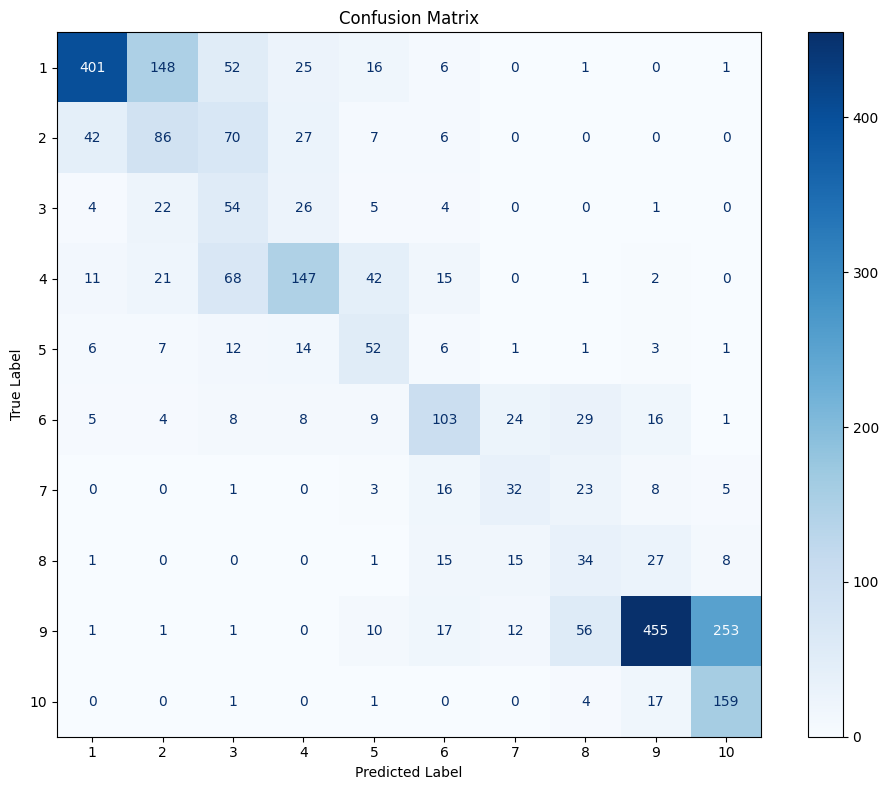

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true, final_preds)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[i+1 for i in range(10)])

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [17]:
# ---- Save predictions alongside ground truth for prompt-engineering comparison ----
results_df = test_df.copy()
results_df['pred_class']     = final_preds
results_df['pred_score']     = final_preds + 1   # convert 0-indexed back to 1-10
results_df['pred_rating']    = [RATING_NAMES[p] for p in final_preds]
results_df.to_csv(f'{OUTPUT_DIR}/test_predictions.csv', index=False)
print(f'Predictions saved to {OUTPUT_DIR}/test_predictions.csv')
print('(This file will be used for prompt engineering comparison in Phase 4)')

Predictions saved to ./roberta_mental_severity/test_predictions.csv
(This file will be used for prompt engineering comparison in Phase 4)


## 11. Save Model

In [18]:
save_path = f'{OUTPUT_DIR}/best_model'
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f'Model + tokenizer saved to {save_path}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model + tokenizer saved to ./roberta_mental_severity/best_model


# To Save Results

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
import shutil

shutil.make_archive(
    '/content/roberta_mental_severity',
    'zip',
    OUTPUT_DIR
)

print("ZIP file created!")

ZIP file created!


In [21]:
import shutil

shutil.copy(
    '/content/roberta_mental_severity.zip',
    '/content/drive/MyDrive/roberta_mental_severity.zip'
)

print("Saved to Google Drive!")

Saved to Google Drive!
